In [81]:
from pyGmsh import pyGmsh
from pyGmsh import Numberer, FEMData
import numpy as np
import openseespy.opensees as ops
from pathlib import Path

In [82]:
model_iges_path = Path(r'C:\Users\nmora\Github\pyGmsh\acad') / 'Frame3D.iges'
assert model_iges_path.exists(), model_iges_path

m1 = pyGmsh(
    model_name='Frame3D_story',
    verbose=True
)
m1.initialize()

m1.model.load_iges(
    file_path=model_iges_path,
    highest_dim_only=False
)

m1.model.remove_duplicates(tolerance=1)
m1.make_conformal(tolerance=1.0)
m1.model.remove_duplicates(tolerance=1)
m1.model.sync()

m1.model.selection.select_points(on_plane=("z", 0, 1e-3)).to_physical("base_supports")
m1.model.selection.select_curves(aligned="z").to_physical("columns")
m1.model.selection.select_surfaces(on_plane=("z", 3000, 1e-3)).to_physical("slab")

m1.model.viewer()

m1.mesh.clear()

col_tops = m1.model.selection.select_points(on_plane=("z", 3000, 1e-3))
print(f"Column-top nodes: {col_tops.to_tags()}")

(m1.mesh
     .set_size_sources(from_points=True, extend_from_boundary=True)
     .set_global_size(3000)
     .set_size(col_tops.to_tags(), 1000)
     .generate(dim=2)
     .remove_duplicate_nodes()
     .remove_duplicate_elements())

m1.mesh.viewer()

Gmsh version: 4.15.1
[Model] loaded IGES ← Frame3D.iges  {2: 6, 1: 36, 0: 72}
[Model] remove_duplicates(tolerance=1): merged {0: 12, 1: 7} entities (before={0: 48, 1: 36, 2: 6, 3: 0}, after={0: 36, 1: 29, 2: 6, 3: 0})
[Model] make_conformal(dims=[0, 1, 2], tolerance=1.0): entity delta={} (before={0: 36, 1: 29, 2: 6, 3: 0}, after={0: 36, 1: 29, 2: 6, 3: 0})
[Model] remove_duplicates(tolerance=1): merged {} entities (before={0: 36, 1: 29, 2: 6, 3: 0}, after={0: 36, 1: 29, 2: 6, 3: 0})
[Model] OCC kernel synchronised
[Selection] select dim=0 → 12 / 36 entities
[PhysicalGroups] add(dim=0, entities=[26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48]) → pg_tag=1, name='base_supports'
[Selection] select dim=1 → 12 / 29 entities
[PhysicalGroups] add(dim=1, entities=[25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]) → pg_tag=2, name='columns'
[Selection] select dim=2 → 6 / 6 entities
[PhysicalGroups] add(dim=2, entities=[1, 2, 3, 4, 5, 6]) → pg_tag=3, name='slab'
[picker] closed — 0 physical group(

In [83]:
m1.physical.summary()


--- Physical Groups ---
                     name  n_entities                                     entity_tags
dim pg_tag                                                                           
0   1       base_supports          12  26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48
1   2             columns          12  25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36
2   3                slab           6                                1, 2, 3, 4, 5, 6


,,name,n_entities,entity_tags
dim,pg_tag,,,
0,1,base_supports,12,"26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48"
1,2,columns,12,"25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36"
2,3,slab,6,"1, 2, 3, 4, 5, 6"


In [84]:
m1.physical.get_nodes(dim=0, tag=1)

[PhysicalGroups] get_nodes(dim=0, pg='base_supports') → 12 nodes


{'tags': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24]),
 'coords': array([[ 9.09494702e-13,  7.00000000e+03,  0.00000000e+00],
        [ 8.00000000e+03,  7.00000000e+03,  0.00000000e+00],
        [ 5.00000000e+03,  7.00000000e+03,  0.00000000e+00],
        [ 1.30000000e+04,  7.00000000e+03,  0.00000000e+00],
        [ 1.30000000e+04, -9.09494702e-13,  0.00000000e+00],
        [ 9.09494702e-13,  4.00000000e+03,  0.00000000e+00],
        [ 8.00000000e+03,  4.00000000e+03,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 1.30000000e+04,  4.00000000e+03,  0.00000000e+00],
        [ 8.00000000e+03, -9.09494702e-13,  0.00000000e+00],
        [ 5.00000000e+03, -9.09494702e-13,  0.00000000e+00],
        [ 5.00000000e+03,  4.00000000e+03,  0.00000000e+00]])}

In [85]:
m1.mesh.renumber_mesh(base=1)

[Mesh] get_nodes → 170 nodes
[Mesh] get_elements → 250 elements (1 types)
[Mesh] renumber_mesh(method='simple'): 170 nodes, 250 elements, bandwidth=156


In [86]:
m1.physical.get_nodes(dim=0, tag=1)

[PhysicalGroups] get_nodes(dim=0, pg='base_supports') → 12 nodes


{'tags': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24]),
 'coords': array([[ 9.09494702e-13,  7.00000000e+03,  0.00000000e+00],
        [ 8.00000000e+03,  7.00000000e+03,  0.00000000e+00],
        [ 5.00000000e+03,  7.00000000e+03,  0.00000000e+00],
        [ 1.30000000e+04,  7.00000000e+03,  0.00000000e+00],
        [ 1.30000000e+04, -9.09494702e-13,  0.00000000e+00],
        [ 9.09494702e-13,  4.00000000e+03,  0.00000000e+00],
        [ 8.00000000e+03,  4.00000000e+03,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 1.30000000e+04,  4.00000000e+03,  0.00000000e+00],
        [ 8.00000000e+03, -9.09494702e-13,  0.00000000e+00],
        [ 5.00000000e+03, -9.09494702e-13,  0.00000000e+00],
        [ 5.00000000e+03,  4.00000000e+03,  0.00000000e+00]])}

In [87]:
fem_data = m1.mesh.get_fem_data()

[Mesh] get_nodes → 170 nodes
[Mesh] get_elements → 250 elements (1 types)
[Mesh] get_fem_data(dim=2) → FEMData: 170 nodes, 250 elements, bandwidth=156


In [88]:
m1.mesh.viewer()

[MeshViewer] closed — 0 nodes picked, 0 elements picked, 0 BRep patches selected


In [89]:
m1.finalize()

In [90]:
fem_data.summary()

'FEMData: 170 nodes, 250 elements, bandwidth=156'

In [91]:
fem_data.element_ids

array([ 37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,
        50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,
        63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,
        76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,
        89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101,
       102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114,
       115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127,
       128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140,
       141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153,
       154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166,
       167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179,
       180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192,
       193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205,
       206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 21

In [92]:
fem_data.connectivity

array([[ 88,  96,  92],
       [ 93,  96,  88],
       [ 89,  95,  94],
       [ 91,  95,  89],
       [ 42,  88,  41],
       [ 45,  90,  44],
       [ 48,  89,  47],
       [ 39,  87,  38],
       [ 38,  91,  37],
       [ 40,  92,  39],
       [ 44,  93,  43],
       [ 46,  94,  45],
       [ 39,  92,  87],
       [ 87,  91,  38],
       [ 45,  94,  90],
       [ 90,  93,  44],
       [ 23,  97,  40],
       [  5,  98,  42],
       [ 11, 100,  48],
       [ 37, 100,  11],
       [ 41,  97,  23],
       [ 43,  98,   5],
       [  1,  99,  46],
       [ 47,  99,   1],
       [ 40,  97,  92],
       [ 93,  98,  43],
       [ 46,  99,  94],
       [ 91, 100,  37],
       [ 87,  96,  95],
       [ 95,  96,  90],
       [ 89,  99,  47],
       [ 42,  98,  88],
       [ 48, 100,  89],
       [ 88,  97,  41],
       [ 87,  95,  91],
       [ 94,  95,  90],
       [ 90,  96,  93],
       [ 92,  96,  87],
       [ 89, 100,  91],
       [ 88,  98,  93],
       [ 94,  99,  89],
       [ 92,  97

In [93]:
len(fem_data.node_ids)

170

In [94]:
from pyGmsh.viewers import GeomTransfViewer

viewer = GeomTransfViewer()
viewer.show(node_i=[0, 0, 0], node_j=[0, 0, 3], vecxz=[1, 0, 0])

In [95]:
for node_id, coords in zip(fem_data.node_ids, fem_data.node_coords):
    print(f"Node {node_id}: {coords}")

Node 1: [9.09494702e-13 7.00000000e+03 3.00000000e+03]
Node 2: [9.09494702e-13 7.00000000e+03 0.00000000e+00]
Node 3: [8000. 7000. 3000.]
Node 4: [8000. 7000.    0.]
Node 5: [5000. 7000. 3000.]
Node 6: [5000. 7000.    0.]
Node 7: [13000.  7000.  3000.]
Node 8: [13000.  7000.     0.]
Node 9: [ 1.30000000e+04 -9.09494702e-13  3.00000000e+03]
Node 10: [ 1.30000000e+04 -9.09494702e-13  0.00000000e+00]
Node 11: [9.09494702e-13 4.00000000e+03 3.00000000e+03]
Node 12: [9.09494702e-13 4.00000000e+03 0.00000000e+00]
Node 13: [8000. 4000. 3000.]
Node 14: [8000. 4000.    0.]
Node 15: [   0.    0. 3000.]
Node 16: [0. 0. 0.]
Node 17: [13000.  4000.  3000.]
Node 18: [13000.  4000.     0.]
Node 19: [ 8.00000000e+03 -9.09494702e-13  3.00000000e+03]
Node 20: [ 8.00000000e+03 -9.09494702e-13  0.00000000e+00]
Node 21: [ 5.00000000e+03 -9.09494702e-13  3.00000000e+03]
Node 22: [ 5.00000000e+03 -9.09494702e-13  0.00000000e+00]
Node 23: [5000. 4000. 3000.]
Node 24: [5000. 4000.    0.]
Node 25: [9.09494702e-

In [96]:
fem_data.physical.get_nodes(dim=0, tag=1)

{'tags': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24]),
 'coords': array([[ 9.09494702e-13,  7.00000000e+03,  0.00000000e+00],
        [ 8.00000000e+03,  7.00000000e+03,  0.00000000e+00],
        [ 5.00000000e+03,  7.00000000e+03,  0.00000000e+00],
        [ 1.30000000e+04,  7.00000000e+03,  0.00000000e+00],
        [ 1.30000000e+04, -9.09494702e-13,  0.00000000e+00],
        [ 9.09494702e-13,  4.00000000e+03,  0.00000000e+00],
        [ 8.00000000e+03,  4.00000000e+03,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 1.30000000e+04,  4.00000000e+03,  0.00000000e+00],
        [ 8.00000000e+03, -9.09494702e-13,  0.00000000e+00],
        [ 5.00000000e+03, -9.09494702e-13,  0.00000000e+00],
        [ 5.00000000e+03,  4.00000000e+03,  0.00000000e+00]])}

In [97]:
fem_data.physical.get_nodes(dim=2, tag=3)

{'tags': array([  1,   3,   5,   7,   9,  11,  13,  15,  17,  19,  21,  23,  37,
         38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
         51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
         64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
         77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
         90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
        103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
        116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
        129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
        142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
        155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
        168, 169, 170]),
 'coords': array([[ 9.09494702e-13,  7.00000000e+03,  3.00000000e+03],
        [ 8.00000000e+03,  7.00000000e+03,  3.00000000e+03],
        [ 5.00000000e+03,  7.000

In [98]:
fem_data.physical.get_elements(dim=2, tag=3)

{'element_ids': array([ 37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,
         50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,
         63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,
         76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,
         89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101,
        102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114,
        115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127,
        128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140,
        141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153,
        154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166,
        167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179,
        180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192,
        193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205,
        206, 207, 208, 209, 210, 211

In [ ]:
import openseespy.opensees as ops
import pandas as pd

ops.wipe()
ops.model('basic', '-ndm', 3, '-ndf', 6)

linear_time_series_tag = 1
ops.timeSeries('Linear', linear_time_series_tag)

# Nodes
for node_id, coords in zip(fem_data.node_ids, fem_data.node_coords):
    ops.node(int(node_id), *coords)

# Boundary conditions
base_nodes = fem_data.physical.get_nodes(dim=0, tag=1)['tags']
for node_id in base_nodes:
    ops.fix(int(node_id), 1, 1, 1, 1, 1, 1)

# Section
plate_section = 1
ops.section('ElasticMembranePlateSection', plate_section, 200000, 0.3, 300, 0)
column_section = 2
# section('Elastic', secTag, E_mod, A, Iz, Iy, G_mod, Jxx, alphaY=None, alphaZ=None)
ops.section('Elastic', column_section, 200000, 300*300, 300**4/12, 300**4/12, 200000/2, 300**4/12)

# geomTransf('Linear', transfTag, *vecxz, '-jntOffset', *dI, *dJ)
linear_tag = 1
ops.geomTransf('Linear', linear_tag, *[1,0,0])

# Elements
for elem_id, (node_i, node_j) in zip(fem_data.physical.get_elements(dim=1, tag=2)['element_ids'], fem_data.physical.get_elements(dim=1, tag=2)['connectivity']):
    # element('elasticBeamColumn', eleTag, *eleNodes, secTag, transfTag, <'-mass', mass>, <'-cMass'>, <'-release', releaseCode>)
    ops.element('elasticBeamColumn', int(elem_id), int(node_i), int(node_j), column_section, linear_tag)

for elem_id, (node_i, node_j, node_k) in zip(fem_data.physical.get_elements(dim=2, tag=3)['element_ids'], fem_data.physical.get_elements(dim=2, tag=3)['connectivity']):
    ops.element('ShellDKGT', int(elem_id), int(node_i), int(node_j), int(node_k), plate_section)

# Load
shell_pattern_tag = 1
ops.pattern('Plain', shell_pattern_tag, linear_time_series_tag)

q = -1.0  # N/mm² pressure (downward)

slab_tag = fem_data.physical.get_tag(2, "slab")
slab_elems = fem_data.physical.get_elements(2, slab_tag)

# Build a nodal load accumulator
nodal_fz = {}

for conn in slab_elems['connectivity']:
    ni, nj, nk = int(conn[0]), int(conn[1]), int(conn[2])

    # Node indices for coordinate lookup
    idx_i = np.searchsorted(fem_data.node_ids, ni)
    idx_j = np.searchsorted(fem_data.node_ids, nj)
    idx_k = np.searchsorted(fem_data.node_ids, nk)

    pi = fem_data.node_coords[idx_i]
    pj = fem_data.node_coords[idx_j]
    pk = fem_data.node_coords[idx_k]

    # Triangle area = 0.5 * ||(pj - pi) × (pk - pi)||
    area = 0.5 * np.linalg.norm(np.cross(pj - pi, pk - pi))

    # Consistent nodal load: q * A / 3 per node
    fz = q * area / 3.0

    for n in (ni, nj, nk):
        nodal_fz[n] = nodal_fz.get(n, 0.0) + fz

# Apply accumulated forces
for nid, fz in nodal_fz.items():
    ops.load(nid, 0.0, 0.0, fz, 0.0, 0.0, 0.0)

# load(nodeTag, *loadValues)
ops.load(104, *[0,0,-1000,0,0,0])

# Analysis
ops.constraints('Transformation')
ops.numberer('RCM')
ops.system('BandGeneral')
ops.test('NormDispIncr', 1.0e-6, 10)
ops.algorithm('Newton')
ops.integrator('LoadControl', 0.1)
ops.analysis('Static')

ok = ops.analyze(10)
if ok != 0:
    print("Analysis failed to converge")
else:
    print("Analysis completed successfully")

Analysis completed successfully


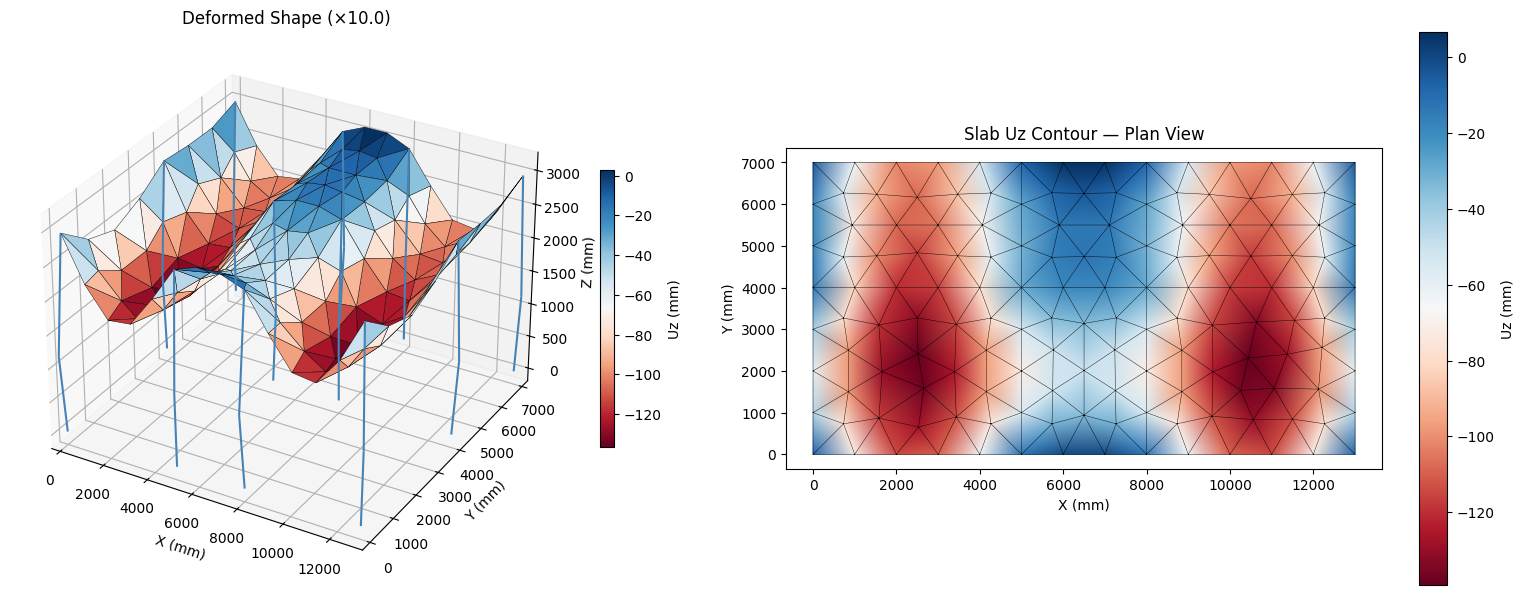

Max downward Uz:  -139.1472 mm
Max upward   Uz:  6.6045 mm
Max |Ux|:         19.2588 mm
Max |Uy|:         11.4602 mm


In [100]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
import numpy as np

# ── Extract displacements from OpenSees ──────────────────────────
disp = np.array([ops.nodeDisp(int(nid)) for nid in fem_data.node_ids])  # (N, 6)
coords = fem_data.node_coords  # (N, 3)

# Build a quick lookup: node_id → index
nid_to_idx = {int(nid): i for i, nid in enumerate(fem_data.node_ids)}

# ── Deformed coordinates ─────────────────────────────────────────
scale = 10.0  # amplification factor for visualization
deformed = coords + scale * disp[:, :3]

# ── Slab: triangular shell patches ──────────────────────────────
slab_tag = fem_data.physical.get_tag(2, "slab")
slab = fem_data.physical.get_elements(2, slab_tag)

slab_tri_idx = np.array([
    [nid_to_idx[int(n)] for n in row]
    for row in slab['connectivity']
])

# Vertical displacement (Uz) per node — for coloring
Uz = disp[:, 2]

fig = plt.figure(figsize=(16, 6))

# ── Plot 1: 3D deformed shape with Uz contour ───────────────────
ax1 = fig.add_subplot(121, projection='3d')

# Slab triangles (deformed)
tri_verts_def = deformed[slab_tri_idx]  # (n_tri, 3, 3)
tri_colors = Uz[slab_tri_idx].mean(axis=1)  # avg Uz per triangle

poly = Poly3DCollection(tri_verts_def, edgecolors='k', linewidths=0.3)
poly.set_array(np.array(tri_colors))
poly.set_cmap('RdBu')
poly.set_clim(tri_colors.min(), tri_colors.max())
ax1.add_collection3d(poly)

# Columns (deformed)
col_tag = fem_data.physical.get_tag(1, "columns")
cols = fem_data.physical.get_elements(1, col_tag)

col_lines = []
for ni, nj in cols['connectivity']:
    i, j = nid_to_idx[int(ni)], nid_to_idx[int(nj)]
    col_lines.append([deformed[i], deformed[j]])

ax1.add_collection3d(
    Line3DCollection(col_lines, colors='steelblue', linewidths=1.5)
)

# Axis limits from deformed coords
all_pts = deformed
pad = 200
ax1.set_xlim(all_pts[:, 0].min() - pad, all_pts[:, 0].max() + pad)
ax1.set_ylim(all_pts[:, 1].min() - pad, all_pts[:, 1].max() + pad)
ax1.set_zlim(all_pts[:, 2].min() - pad, all_pts[:, 2].max() + pad)
ax1.set_xlabel('X (mm)')
ax1.set_ylabel('Y (mm)')
ax1.set_zlabel('Z (mm)')
ax1.set_title(f'Deformed Shape (×{scale})')
fig.colorbar(poly, ax=ax1, shrink=0.5, label='Uz (mm)')

# ── Plot 2: plan view Uz contour on slab ────────────────────────
ax2 = fig.add_subplot(122)

# Use original (undeformed) XY for plan view
slab_node_ids = fem_data.physical.get_nodes(2, slab_tag)['tags']
slab_node_idx = np.array([nid_to_idx[int(n)] for n in slab_node_ids])

x_slab = coords[slab_node_idx, 0]
y_slab = coords[slab_node_idx, 1]
uz_slab = Uz[slab_node_idx]

# Triangulation in plan using the slab connectivity
# Map global indices to local slab indices
slab_nid_to_local = {int(nid): i for i, nid in enumerate(slab_node_ids)}
local_tri = np.array([
    [slab_nid_to_local[int(n)] for n in row]
    for row in slab['connectivity']
])

triang = mtri.Triangulation(x_slab, y_slab, triangles=local_tri)
tc = ax2.tripcolor(triang, uz_slab, cmap='RdBu', shading='gouraud')
ax2.triplot(triang, 'k-', linewidth=0.3)
ax2.set_xlabel('X (mm)')
ax2.set_ylabel('Y (mm)')
ax2.set_title('Slab Uz Contour — Plan View')
ax2.set_aspect('equal')
fig.colorbar(tc, ax=ax2, label='Uz (mm)')

plt.tight_layout()
plt.show()

# ── Summary stats ────────────────────────────────────────────────
print(f"Max downward Uz:  {Uz.min():.4f} mm")
print(f"Max upward   Uz:  {Uz.max():.4f} mm")
print(f"Max |Ux|:         {np.abs(disp[:, 0]).max():.4f} mm")
print(f"Max |Uy|:         {np.abs(disp[:, 1]).max():.4f} mm")